In [104]:
import os, sys
import json, yaml
import numpy as np
import pandas as pd
import pickle

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import tbparse
from IPython.display import display

from dpvtex.dpvt_data import load_nicknames_dict

### Inject Parameters from Papermill

In [ ]:
# Parameter Options
use_relative_paths_to_output_dir = True
# options for plotting
plot_details = False
# Details for performance plots
fix_sites = False
fix_num_leaves = False
fix_model = False
# Set all details at once
plot_auroc_details = True
if plot_auroc_details:
    show_data_source = True
    fix_sites = True
    fix_num_leaves = True
    fix_model = True
# Useful for pp on same number of leaves
ignore_sites_and_num_leaves = False

# Parameter Paths
working_dir = "."
output_dir = "_output/run.TODAY"
results_dir = "_output/run.TODAY/result_csvs_and_pdfs"
summary_csv_path = "_output/run.TODAY/result_csvs_and_pdfs/summary.csv"
baseline_csv_path = "_output/run.TODAY/result_csvs_and_pdfs/baseline_summary.csv"
config_path = "_output/run.TODAY/config.yaml"
data_nicknames_path = "_output/run.TODAY/data_nicknames.json"

In [ ]:
if use_relative_paths_to_output_dir:
    results_dir = f"{output_dir}/result_csvs_and_pdfs"
    summary_csv_path = f"{output_dir}/result_csvs_and_pdfs/summary.csv"
    baseline_csv_path = f"{output_dir}/result_csvs_and_pdfs/baseline_summary.csv"
    config_path = f"{output_dir}/result_csvs_and_pdfs/config.yaml"
    data_nicknames_path = f"{output_dir}/result_csvs_and_pdfs/data_nicknames.json"

In [108]:
# Verify that paths exist
for path in [working_dir, output_dir, results_dir, summary_csv_path, baseline_csv_path, config_path, data_nicknames_path]:
    if "cpu_" in path or "gpu_" in path:
        path = path.replace("cpu_", "").replace("gpu_", "")
    if os.path.exists(path):
        print(f"file exists: {path}")
    else:
        if path == baseline_csv_path:
            baseline_csv_path = None
        print(f"file does NOT exist: {path}")

file exists: /home/lcollien/git/dpvt-experiments-1/train
file exists: /home/lcollien/git/dpvt-experiments-1/train/_output/run.TODAY
file exists: /home/lcollien/git/dpvt-experiments-1/train/_output/run.TODAY/result_csvs_and_pdfs
file exists: /home/lcollien/git/dpvt-experiments-1/train/_output/run.TODAY/result_csvs_and_pdfs/summary.csv
file exists: /home/lcollien/git/dpvt-experiments-1/train/_output/run.TODAY/result_csvs_and_pdfs/baseline_summary.csv
file exists: /home/lcollien/git/dpvt-experiments-1/train/_output/run.TODAY/result_csvs_and_pdfs/config.yaml
file exists: /home/lcollien/git/dpvt-experiments-1/train/_output/run.TODAY/result_csvs_and_pdfs/data_nicknames.json


# Load and Format Data

In [109]:
def display_all(df, max_rows=None, max_cols=None):
    with pd.option_context('display.max_rows', max_rows, 'display.max_columns', max_cols):
        display(df)

In [110]:
def load_data(file_path, file_type=None):
    if "cpu_" in file_path or "gpu_" in file_path:
        file_path = file_path.replace("cpu_", "").replace("gpu_", "")
    # if file type not given, infer from file extension
    if file_type == None:
        file_type = file_path.split('.')[-1]

    if file_type in ['json']:
        with open(file_path, 'r') as file:
            data = json.load(file)
        return data

    elif file_type in ['yaml', 'yml']:
        with open(file_path, "r") as file:
            data = yaml.safe_load(file)
        return data

    elif file_type in ['pickle', 'pkl', 'p']:
        with open(file_path, 'rb') as file:
            data = pickle.load(file)
        return data

    else:
        print(f'load failed: "{file_type}" file type not recognized.')

In [111]:
# load config file
config_data = load_data(config_path)
config_yaml_str = yaml.dump(config_data, default_flow_style=False, sort_keys=False)

data_pairs = dict(zip(config_data['train_data'], config_data['test_data']))

# check whether there are datapairs with spr and without spr in training and testing
mixed_source_training = False
mixed_source_testing = False
# check if 'spr' is in  some test_data entries, but not all
spr_train_data = [s for s in config_data['train_data'] if 'spr' in s]
if len(spr_train_data) > 0 and len(spr_train_data) < len(config_data['train_data']):
    mixed_source_training = True
spr_test_data = [s for s in config_data['test_data'] if 'spr' in s]
if len(spr_test_data) > 0 and len(spr_test_data) < len(config_data['test_data']):
    mixed_source_testing = True

In [112]:
# load data nicknames and absolute paths
data_nicknames_dict = load_nicknames_dict(data_nicknames_path)
for name,path in data_nicknames_dict.items():
    data_nicknames_dict[name] = f'{working_dir}/{path}'
for name,path in data_nicknames_dict.items():
    if not os.path.exists(path):
        print(f"file does NOT exist: {name} => {path}")

file does NOT exist: larch_harrington_subset_150_to_200_seqs_50_alignments_2025_03_24_2025-03-26_test_spr => /home/lcollien/git/dpvt-experiments-1/train/../data/larch_harrington_subset_150_to_200_seqs_50_alignments_2025_03_24_2025-03-26_test_spr.p
file does NOT exist: larch_harrington_subset_150_to_200_seqs_50_alignments_2025_03_24_2025-03-26_train_spr => /home/lcollien/git/dpvt-experiments-1/train/../data/larch_harrington_subset_150_to_200_seqs_50_alignments_2025_03_24_2025-03-26_train_spr.p
file does NOT exist: larch_harrington_subset_100_to_150_seqs_50_alignments_2025-03-25_test_spr => /home/lcollien/git/dpvt-experiments-1/train/../data/larch_harrington_subset_100_to_150_seqs_50_alignments_2025-03-25_test_spr.p
file does NOT exist: larch_harrington_subset_100_to_150_seqs_50_alignments_2025-03-25_train_spr => /home/lcollien/git/dpvt-experiments-1/train/../data/larch_harrington_subset_100_to_150_seqs_50_alignments_2025-03-25_train_spr.p


In [113]:
# load results summary
summary_df = pd.read_csv(summary_csv_path)
if baseline_csv_path:
    baseline_summary_df = pd.read_csv(baseline_csv_path)
    # Add data from baseline df to summary df for auroc plots
    summary_df = pd.concat([summary_df, baseline_summary_df], ignore_index=True)
display(summary_df)

,Unnamed: 0,model,train_data,test_data,device,timestamp,param_id,n_hyperparam_trials,learning_rate,batch_size,...,hyper_json_path,hyper_llog_path,hyper_benchmark_path,hyper_checkpoint_path,train_llog_path,train_benchmark_path,train_clog_path,train_checkpoint_path,test_llog_path,test_checkpoint_path
0,0,TraverseNN,larch_alisim_alignment_10_seq_100_sites_500_al...,larch_alisim_alignment_10_seq_100_sites_200_al...,cpu,TODAY,Param0,0.0,0.00005,4.0,...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...
1,0,TraverseNN,larch_alisim_alignment_10_seq_100_sites_500_al...,larch_alisim_alignment_10_seq_50_sites_200_alg...,cpu,TODAY,Param0,0.0,0.00005,4.0,...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...
2,0,TraverseNN,larch_alisim_alignment_10_seq_100_sites_500_al...,larch_alisim_alignment_15_seq_100_sites_200_al...,cpu,TODAY,Param0,0.0,0.00005,4.0,...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...
3,0,TraverseNN,larch_alisim_alignment_10_seq_100_sites_500_al...,larch_alisim_alignment_15_seq_50_sites_200_alg...,cpu,TODAY,Param0,0.0,0.00005,4.0,...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...
4,0,TraverseNN,larch_alisim_alignment_10_seq_100_sites_500_al...,larch_alisim_alignment_20_seq_100_sites_200_al...,cpu,TODAY,Param0,0.0,0.00005,4.0,...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...,/home/lcollien/git/dpvt-experiments-1/train/_o...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,0,BaselineReversion,baseline,larch_alisim_alignment_10_seq_50_sites_200_alg...,cpu,TODAY,baseline,NaN,NaN,NaN,...,none,none,none,none,none,none,none,none,none,/home/lcollien/git/dpvt-experiments-1/train/_o...
224,0,BaselineReversion,baseline,larch_alisim_alignment_15_seq_100_sites_200_al...,cpu,TODAY,baseline,NaN,NaN,NaN,...,none,none,none,none,n

In [114]:
def get_stats_from_data(data_path):
    '''
    Extracts the number of trees, leaves, and sites from a dataset.
    '''
    if data_path == None:
        data_stats = {
            'num_trees': None,
            'num_leaves': None,
            'num_sites': None,
        }
        return data_stats
    data_stats = {
        'num_trees': None,
        'num_leaves': [],
        'num_sites': [],
    }
    data_dict = load_data(data_path)
    for i,(tree,vec) in enumerate(data_dict.items()):
        num_leaves = len(tree.get_leaves())
        num_sites = [len(x.sequence) for x in list(tree.get_leaves())][0]
    data_stats['num_trees'] = len(data_dict.items())
    data_stats['num_leaves'] = num_leaves + 1 # root leaf
    data_stats['num_sites'] = num_sites
    return data_stats


def get_all_data_names_from_summary_df(summary_df):
    data_names = []
    data_names += list(set(summary_df.train_data))
    data_names += list(set(summary_df.test_data))
    data_names = list(set(data_names))
    return data_names
  

def build_data_stats_dict_from_summary_df(summary_df):
    '''
    Build dict of number of trees, leaves, and sites for each dataset in summary_df.
    '''
    data_stats = {}
    data_names = get_all_data_names_from_summary_df(summary_df)
    for i,data_name in enumerate(data_names):
        if i+1 % 5 == 0:
            print(f'i={i}')
        elif "baseline" not in data_name:
            train_data_path = data_nicknames_dict[data_name]
        else:
            train_data_path = None    
        data_stats[data_name] = get_stats_from_data(train_data_path)

    return data_stats

In [115]:
# Functions for pulling data stats from name.

def extract_num_leaves(row):
    '''
    Extracts number of leaves from a row containing test or training data labels. This only works for alisim and perfect phylogeny data that follows specific naming rules and should eventually be replaces by something more sophisticated, e.g. adding num_leaves and other stats like that when creating initial csvs.
    '''
    if 'alisim' in row:
        return row.split('_')[1]  # Take the second entry after splitting by '_'
    elif 'leaf' in row:
        return row.split('leaf')[0]  # Take the part after 'leaf'
    elif 'perfect' in row:
        return row.split('_')[1]
    else:
        return None


def extract_num_sites(row):
    '''
    Extracts number of leaves from a row containing test or training data labels. This only works for alisim data that follows sepcific naming rules and should eventually be replaces by something more sophisticated, e.g. adding num_leaves and other stats like that when creating initial csvs.
    '''
    if 'alisim' in row:
        return row.split("_")[3]
    elif 'perfect' in row:
        return row.split('_')[7]
    else:
        return None


def extract_num_trees(row):
    '''
    Extracts number of leaves from a row containing test or training data labels. This only works for alisim data that follows sepcific naming rules and should eventually be replaces by something more sophisticated, e.g. adding num_leaves and other stats like that when creating initial csvs.
    '''
    if 'pp' in row:
        return row.split("trees")[0].split("_")[-1]
    elif 'perfect' in row:
        return row.split('_')[3]
    else:
        return None

In [116]:
# Add summary columns
summary_df["label"] = summary_df[["model","train_data","test_data", "param_id"]].apply(lambda x:"\n".join(x), axis=1)
summary_df["percent_epochs"] = summary_df["train_epochs"]/summary_df["max_epochs"]
summary_df["model_and_train_data"] = summary_df["model"].astype(str) + "-" + summary_df["train_data"].astype(str)

data_stats = build_data_stats_dict_from_summary_df(summary_df)
summary_df["train_num_leaves"] = [data_stats[x]["num_leaves"] for x in summary_df["train_data"]]
summary_df["train_num_sites"] = [data_stats[x]["num_sites"] for x in summary_df["train_data"]]
summary_df["train_num_trees"] = [data_stats[x]["num_trees"] for x in summary_df["train_data"]]
summary_df["test_num_leaves"] = [data_stats[x]["num_leaves"] for x in summary_df["test_data"]]
summary_df["test_num_sites"] = [data_stats[x]["num_sites"] for x in summary_df["test_data"]]
summary_df["test_num_trees"] = [data_stats[x]["num_trees"] for x in summary_df["test_data"]]

# Convert all columns with number of x to ints
num_columns = [
    "train_num_leaves", "train_num_sites", "train_num_trees",
    "test_num_leaves", "test_num_sites", "test_num_trees"
]
for col in num_columns:
    # This converts only non-NaN values to int, keeping NaNs as NaN
    summary_df[col] = summary_df[col].astype('Int64')

# Sort models
model_order = ["TraverseMaxPooling", "TraverseAvgPooling", "TraverseNN", "BaselineReversion"]
summary_df["model"] = pd.Categorical(summary_df["model"], categories=model_order, ordered=True)

display_all(
    summary_df[["train_data", "train_num_leaves", "train_num_sites", "train_num_trees",
                "test_data", "test_num_leaves", "test_num_sites", "test_num_trees"]],
    max_rows=10,
)

model_list = summary_df["model"].unique()

,train_data,train_num_leaves,train_num_sites,train_num_trees,test_data,test_num_leaves,test_num_sites,test_num_trees
0,larch_alisim_alignment_10_seq_100_sites_500_al...,10,100,1336,larch_alisim_alignment_10_seq_100_sites_200_al...,10,100,572
1,larch_alisim_alignment_10_seq_100_sites_500_al...,10,100,1336,larch_alisim_alignment_10_seq_50_sites_200_alg...,10,50,716
2,larch_alisim_alignment_10_seq_100_sites_500_al...,10,100,1336,larch_alisim_alignment_15_seq_100_sites_200_al...,15,100,548
3,larch_alisim_alignment_10_seq_100_sites_500_al...,10,100,1336,larch_alisim_alignment_15_seq_50_sites_200_alg...,15,50,1686
4,larch_alisim_alignment_10_seq_100_sites_500_al...,10,100,1336,larch_alisim_alignment_20_seq_100_sites_200_al...,20,100,1480
...,...,...,...,...,...,...,...,...
223,baseline,<NA>,<NA>,<NA>,larch_alisim_alignment_10_seq_50_sites_200_alg...,10,50,358
224,baseline,<NA>,<NA>,<NA>,larch_alisim_alignment_15_seq_100_sites_200_al...,15,100,846
225,baseline,<NA>,<NA>,<NA>,larch_alisim_alignment_15_seq_50_sites_200_alg...,15,50,843
226,baseline,<NA>,<NA>,<NA>,larch_alisim_alignment_20_seq_100_sites_200_al...,20,100,740


In [117]:
# reshape data
models = ['model', 'train_data', 'test_data', 'param_id']
hyperparams = ['learning_rate', 'batch_size', 'accum_grad_batches', 'max_epochs', 'feature_length', 'dim_mlp_layers']

# only keep one row per train_data

# train_df = summary_df
# train_df['label'] = train_df['model'].astype(str) + "-" + train_df['train_data'].astype(str)
train_df = summary_df.groupby('model_and_train_data')[hyperparams].first().reset_index()

melt_df = pd.melt(train_df, id_vars='model_and_train_data', var_name='Metric', value_name='Value')
melt_df = melt_df[melt_df.Metric.isin(hyperparams)]
display(melt_df)

,model_and_train_data,Metric,Value
0,BaselineReversion-baseline,learning_rate,NaN
1,TraverseAvgPooling-larch_alisim_alignment_10_s...,learning_rate,0.00005
2,TraverseAvgPooling-larch_alisim_alignment_10_s...,learning_rate,0.00005
3,TraverseAvgPooling-larch_alisim_alignment_15_s...,learning_rate,0.00005
4,TraverseAvgPooling-larch_alisim_alignment_15_s...,learning_rate,0.00005
...,...,...,...
109,TraverseNN-larch_alisim_alignment_10_seq_50_si...,dim_mlp_layers,256.00000
110,TraverseNN-larch_alisim_alignment_15_seq_100_s...,dim_mlp_layers,256.00000
111,TraverseNN-larch_alisim_alignment_15_seq_50_si...,dim_mlp_layers,256.00000
112,TraverseNN-larch_alisim_alignment_20_seq_100_s...,dim_mlp_layers,256.00000


In [118]:
# Ensures plt.subplots() is iterable in the 1x1 base case.
def plt_subplots(*args, **kwargs):
    fig, axs = plt.subplots(*args, **kwargs)
    if not isinstance(axs, np.ndarray):  # Check if it's a single Axes instance
        axs = np.array([axs])
    return fig, axs

# Functions for label formatting (converts to sci formatting for numbers outside given range, truncates to set significant digits)
def truncate_to_significant_digits(x, sig_digits):
    if x == 0:
        return 0
    else:
        magnitude = np.floor(np.log10(abs(x)))
        factor = 10**(sig_digits - magnitude - 1)
        truncated_value = np.floor(x * factor) / factor
        return truncated_value

def num_formatter(x, sig_digits=4, sci_range=[1e-6, 1e6]):
    x = truncate_to_significant_digits(x, sig_digits)
    if (x != 0) and (x < sci_range[0] or x > sci_range[1]):
        return "{:.{}e}".format(x, sig_digits)
    return x

# Testing performance (AUROC and test loss)

In [119]:
def get_evolution_model(data_string):
    """
    Specify data_string to extract the model from test or train data nickname
    """
    data_lower = data_string.lower()  # Convert to lowercase
    if 'alisim' in data_lower:
        if 'gtr' in data_lower:          # Check for 'gtr' in lowercase string
            return 'GTR'
        elif 'hky' in data_lower:        # Check for 'hky' in lowercase string
            return 'HKY'
        else:
            return 'JC'
    return ''

def get_data_source(data_name):
    """
    Specify data_name to extract the data source from - test or train data nickname
    Datasource will be first part of the data string before the first "_".
    """
    if "alisim" in data_name:
        data_name = data_source = "alisim"
    else:
        data_source = data_name.split("_")[0]
    return data_source


def get_axis_labels(s, labels):
    """
    Get the axes labels for the plot.
    s: string to be used as the title of axis (e.g. test or train)
    labels: list of labels that are on ticks at the axis and should be in axis labels
    """
    if len(labels) > 2:
        pairs = [f"{labels[i]} - {labels[i+1]}" for i in range(0, len(labels)-1, 2)]
        if len(labels) % 2: pairs.append(labels[-1])  # Add last element if odd number
        return s + "\n" + '\n'.join(pairs)
    else:
        return s + " " + ' - '.join(labels)

,Unnamed: 0,model,train_data,test_data,device,timestamp,param_id,n_hyperparam_trials,learning_rate,batch_size,...,test_checkpoint_path,label,percent_epochs,model_and_train_data,train_num_leaves,train_num_sites,train_num_trees,test_num_leaves,test_num_sites,test_num_trees
0,0,TraverseNN,larch_alisim_alignment_10_seq_100_sites_500_al...,larch_alisim_alignment_10_seq_100_sites_200_al...,cpu,TODAY,Param0,0.0,0.00005,4.0,...,/home/lcollien/git/dpvt-experiments-1/train/_o...,TraverseNN\nlarch_alisim_alignment_10_seq_100_...,0.28,TraverseNN-larch_alisim_alignment_10_seq_100_s...,10,100,1336,10,100,572
1,0,TraverseNN,larch_alisim_alignment_10_seq_100_sites_500_al...,larch_alisim_alignment_10_seq_50_sites_200_alg...,cpu,TODAY,Param0,0.0,0.00005,4.0,...,/home/lcollien/git/dpvt-experiments-1/train/_o...,TraverseNN\nlarch_alisim_alignment_10_seq_100_...,0.28,TraverseNN-larch_alisim_alignment_10_seq_100_s...,10,100,1336,10,50,716
2,0,TraverseNN,larch_alisim_alignment_10_seq_100_sites_500_al...,larch_alisim_alignment_15_seq_100_sites_200_al...,cpu,TODAY,Param0,0.0,0.00005,4.0,...,/home/lcollien/git/dpvt-experiments-1/train/_o...,TraverseNN\nlarch_alisim_alignment_10_seq_100_...,0.28,TraverseNN-larch_alisim_alignment_10_seq_100_s...,10,100,1336,15,100,548
3,0,TraverseNN,larch_alisim_alignment_10_seq_100_sites_500_al...,larch_alisim_alignment_15_seq_50_sites_200_alg...,cpu,TODAY,Param0,0.0,0.00005,4.0,...,/home/lcollien/git/dpvt-experiments-1/train/_o...,TraverseNN\nlarch_alisim_alignment_10_seq_100_...,0.28,TraverseNN-larch_alisim_alignment_10_seq_100_s...,10,100,1336,15,50,1686
4,0,TraverseNN,larch_alisim_alignment_10_seq_100_sites_500_al...,larch_alisim_alignment_20_seq_100_sites_200_al...,cpu,TODAY,Param0,0.0,0.00005,4.0,...,/home/lcollien/git/dpvt-experiments-1/train/_o...,TraverseNN\nlarch_alisim_alignment_10_seq_100_...,0.28,TraverseNN-larch_alisim_alignment_10_seq_100_s...,10,100,1336,20,100,1480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,0,BaselineReversion,baseline,larch_alisim_alignment_10_seq_50_sites_200_alg...,cpu,TODAY,baseline,NaN,NaN,NaN,...,/home/lcollien/git/dpvt-experiments-1/train/_o...,BaselineReversion\nbaseline\nlarch_alisim_alig...,NaN,BaselineReversion-baseline,<NA>,<NA>,<NA>,10,50,716
218,0,BaselineReversion,baseline,larch_alisim_alignment_15_seq_100_sites_200_al...,cpu,TODAY,baseline,NaN,NaN,NaN,...,/home/lcollien/git/dpvt-experiments-1/train/_o...,BaselineReversion\nbaseline\nlarch_alisim_alig...,NaN,BaselineReversion-baseline,<NA>,<NA>,<NA>,15,100,548
219,0,BaselineReversion,baseline,larch_alisim_alignment_15_seq_50_sites_200_alg...,cpu,TODAY,baseline,NaN,NaN,NaN,...,/home/lcollien/git/dpvt-experiments-1/train/_o...,BaselineReversion\nbaseline\nlarch_alisim_alig...,NaN,BaselineReversion-baseline,<NA>,<NA>,<NA>,15,50,1686
220,0,BaselineReversion,baseline,larch_alisim_alignment_20_seq_100_sites_200_al...,cpu,TODAY,baseline,NaN,NaN,NaN,...,/home/lcollien/git/dpvt-experiments-1/train/_o...,BaselineReversion\nbaseline\nlarch_alisim_alig...,NaN,BaselineReversion-baseline,<NA>,<NA>,<NA>,20,100,1480


/tmp/ipykernel_1727642/1733609111.py:55: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df_for_pivot[col]):
/tmp/ipykernel_1727642/1733609111.py:55: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df_for_pivot[col]):
/tmp/ipykernel_1727642/1733609111.py:55: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df_for_pivot[col]):
/tmp/ipykernel_1727642/1733609111.py:55: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df_for_pivot[col]):
/tmp/ipykern

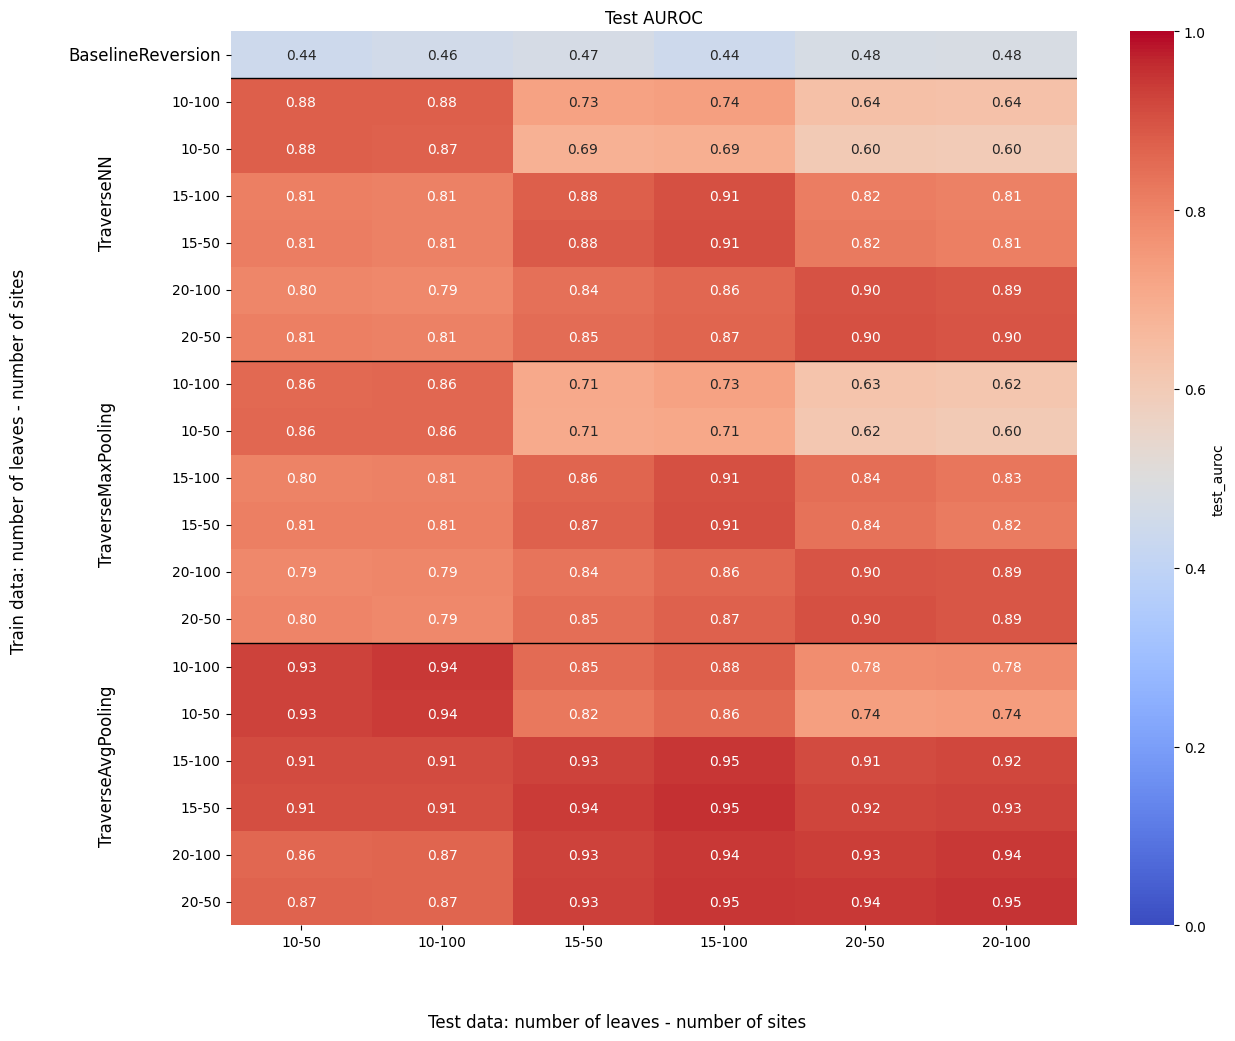

/tmp/ipykernel_1727642/1733609111.py:55: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df_for_pivot[col]):
/tmp/ipykernel_1727642/1733609111.py:55: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df_for_pivot[col]):
/tmp/ipykernel_1727642/1733609111.py:55: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df_for_pivot[col]):
/tmp/ipykernel_1727642/1733609111.py:55: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df_for_pivot[col]):
/tmp/ipykern

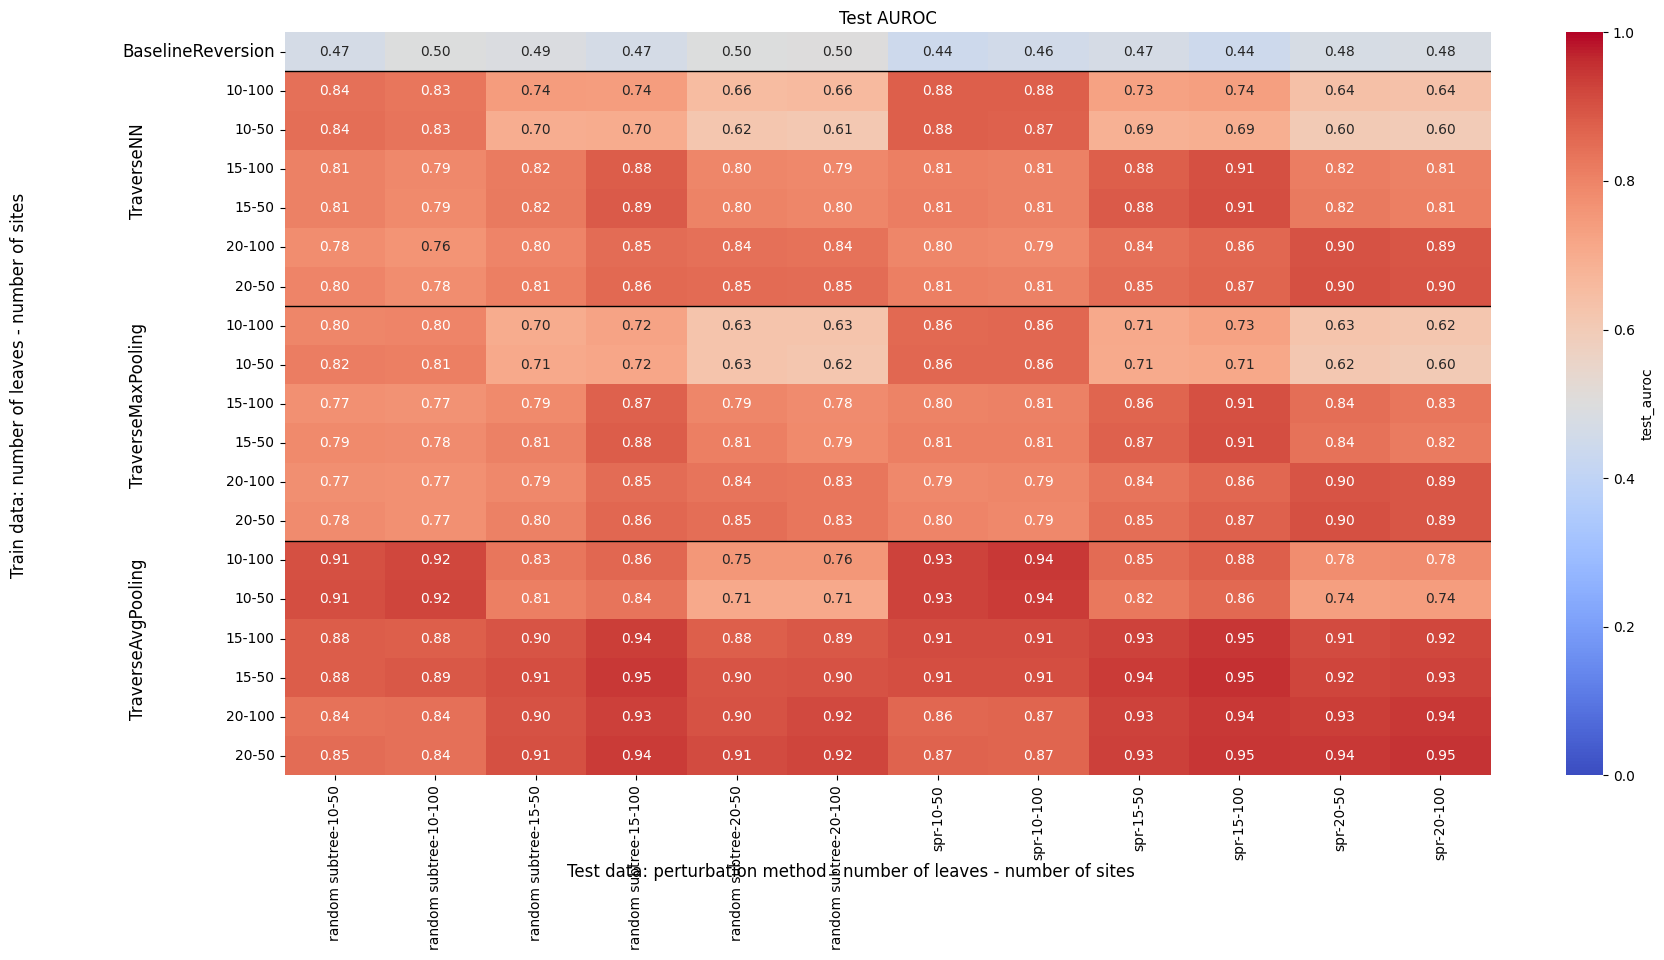

In [202]:
%matplotlib inline
label_dict = {
    "model": "Model",
    "train_data": "Dataset",
    "test_data": "Dataset",
    "train_num_leaves": "Number of Leaves",
    "train_num_sites": "Number of Sites",
    "train_num_trees": "Number of Trees",
    "test_num_leaves": "Number of Leaves",
    "test_num_sites": "Number of Sites",
    "test_num_trees": "Number of Trees",
    "train_perturbation": "Perturbation method",
    "test_perturbation": "Perturbation method",
    "test_data_source": "Data Source",
    "train_data_source": "Data Source",
    "test_data_model": "Evolutionary Model",
    "train_data_model": "Evolutionary Model",
}

def build_heatmap(df, value_name, ignore_sites_and_num_trees=False, mixed_source_training=False, mixed_source_testing=False):
    # format data
    df_sorted = df.sort_values(by=["model", "train_num_leaves", "train_num_sites"])
    indices = ["model"]
    extra_cols = ["train_num_leaves", "train_num_sites"]
    test_cols = ["test_perturbation", "test_num_leaves", "test_num_sites"]
    
    # modifications to plotting
    if ignore_sites_and_num_trees:
        extra_cols = ["train_num_leaves"]
    if len(df_sorted["train_num_leaves"].unique()) == 1:
        extra_cols.remove("train_num_leaves")
    if mixed_source_testing:
        df_sorted["test_perturbation"] = np.where(
            df_sorted["test_data"].str.contains("spr", na=False), 
            "spr",
            "random subtree"
        )
    else:
        df_sorted["test_perturbation"] = ""
        test_cols.remove("test_perturbation")
    if mixed_source_training:
        df_sorted["train_perturbation"] = np.where(
            df_sorted["train_data"].str.contains("spr", na=False), 
            "spr", 
            "random subtree"
        )
        extra_cols = ["train_perturbation"] + extra_cols
    
    for col_name in extra_cols:
        indices.append(col_name)

    if len(indices) > 1:
        df_for_pivot = df_sorted.copy()
        for col in indices + test_cols:
            if pd.api.types.is_categorical_dtype(df_for_pivot[col]):
                df_for_pivot[col] = df_for_pivot[col].astype(str)
            
            # Special handling for columns containing NaNs
            if pd.api.types.is_integer_dtype(df_for_pivot[col]) and pd.isna(df_for_pivot[col]).any():
                df_for_pivot[col] = df_for_pivot[col].astype(str)
            df_for_pivot[col] = df_for_pivot[col].fillna("N/A")

        heatmap_data = df_for_pivot.pivot_table(
            index=indices,
            columns=test_cols,
            values=value_name,
            dropna=False,
        )
        
        # drop all rows with only NaN and then all columns with only Nan.
        heatmap_data = heatmap_data[~heatmap_data.isna().all(axis=1)]
        heatmap_data = heatmap_data.dropna(axis=1, how='all')
    else:
        heatmap_data = df_sorted.pivot(
            index="model",
            columns="test_data",
            values=value_name
        )
    
    # build heatmap with adjusted layout
    fig_width = (len(heatmap_data.columns) * 0.75) + 8  # More space for labels
    fig_height = (len(heatmap_data) * 0.3) + 4
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Create a custom colormap
    cmap = sns.color_palette("coolwarm", as_cmap=True)
    
    # Create a row for the secondary index only
    if isinstance(heatmap_data.index, pd.MultiIndex):
        # Create a new index that shows only the secondary information
        secondary_index = []
        for idx in heatmap_data.index:
            # Format train_num_leaves and train_num_sites as "10-50", "15-100", etc.
            leaves = idx[1] if len(idx) > 1 else ""
            sites = idx[2] if len(idx) > 2 else ""
            secondary_index.append(f"{leaves}-{sites}")
        
        # Create a copy of the DataFrame with the new index
        heatmap_data_display = heatmap_data.copy()
        heatmap_data_display.index = secondary_index
    else:
        heatmap_data_display = heatmap_data
    
    # Set up the heatmap without the MultiIndex
    sns_heatmap = sns.heatmap(
        data=heatmap_data_display,
        annot=True,
        cbar_kws={"label": f"{value_name}"},
        vmin=0, vmax=1,
        cmap=cmap,
        fmt=".2f",
        ax=ax
    )

    # Important: Apply tight layout BEFORE placing the labels
    plt.tight_layout()

    # After creating the heatmap and applying tight_layout
    # Get the actual axis position
    bbox = ax.get_position()
    axis_left = bbox.x0
    axis_height = bbox.height
    axis_bottom = bbox.y0

    # Draw horizontal lines between model groups and add model labels
    if isinstance(heatmap_data.index, pd.MultiIndex):
        models = heatmap_data.index.get_level_values(0).unique()
        
        # First, identify where each model starts and ends
        model_rows = {}
        current_model = None
        start_idx = 0
        
        for i, idx in enumerate(heatmap_data.index):
            model = idx[0]
            
            # New model encountered
            if current_model != model:
                if current_model is not None:
                    model_rows[current_model] = (start_idx, i-1)
                    # Draw horizontal line
                    ax.axhline(y=i, color='black', linewidth=1)
                
                # Start tracking the new model
                current_model = model
                start_idx = i
        
        # Add the last model's range
        if current_model is not None:
            model_rows[current_model] = (start_idx, len(heatmap_data.index)-1)
        
        # Get figure for positioning
        fig = plt.gcf()
        
        # Adjust y-tick labels if baseline model is present (first row)
        add_for_baseline = 0
        if "BaselineReversion" in model_rows:
            add_for_baseline = -0.5
            
        # Place labels for each model
        for model, (start, end) in model_rows.items():
            # Skip the baseline model
            if "Baseline" in model:
                continue
            # Calculate the midpoint row for this model
            center_row = (start + end) / 2 + add_for_baseline
            # Convert to figure coordinates
            fig_y_pos = axis_bottom + ((center_row / len(heatmap_data.index)) * axis_height)
            
            # Add model name as text
            fig.text(
                axis_left - 0.05,  # 5% to the left of the axis
                fig_y_pos,         # Centered position
                model,
                va='center',
                ha='center',
                rotation=90,
                fontsize=12
            )
        
        # Set y-axis label
        ylabel = "Train data: number of leaves - number of sites"
        if mixed_source_training:
            ylabel = "Train data: perturbation method - number of leaves - number of sites"
        fig.text(
            axis_left - 0.12,  # 12% to the left of the axis
            axis_bottom + (axis_height / 2),  # Middle of the axis
            ylabel,
            va='center',
            ha='center',
            rotation=90,
            fontsize=12
        )
        
        # Handle the baseline label if present
        if any("Baseline" in model for model in models):
            yticks = plt.yticks()
            positions = yticks[0]
            labels = [label.get_text() for label in plt.gca().get_yticklabels()]
            baseline_label = ax.get_yticklabels()[0]  # Assuming baseline is the first label
            baseline_label.set_fontsize(12)  # Larger font size
            # Find the baseline model position
            for model, (start, _) in model_rows.items():
                if "Baseline" in model and start < len(labels):
                    labels[start] = "BaselineReversion"
            
            plt.yticks(positions, labels)

        # Make sure there's enough room on the left for the labels
        plt.subplots_adjust(left=0.2)
        
        
        # Add x-axis label at similar distance as y-axis label
        xlabel = "Test data: number of leaves - number of sites"
        if mixed_source_testing:
            xlabel = "Test data: perturbation method - number of leaves - number of sites"
        fig.text(
        axis_left + (bbox.width / 2),  # Center horizontally
        axis_bottom - 0.12,           # Same distance below as y-label is to left
        xlabel,
        va='center',
        ha='center',
        fontsize=12
        )
        ax.set_xlabel('')
        ax.set_title('Test AUROC')
        
        
        # # Add extra space on the left for model labels
        # plt.subplots_adjust(left=0.2)
        plt.tight_layout()
        plt.savefig(f"{results_dir}/{value_name}_heatmap.pdf")
        plt.show()

spr_only_df = summary_df[(summary_df["train_data"].str.contains("spr", na=False) | summary_df["train_data"].str.contains("baseline", na=False)) & summary_df["test_data"].str.contains("spr", na=False)]
display(spr_only_df)
build_heatmap(
    df=spr_only_df,
    value_name="test_auroc",
    mixed_source_training=False,
    mixed_source_testing=False,
    ignore_sites_and_num_trees=ignore_sites_and_num_leaves,
)

build_heatmap(
    df=summary_df,
    value_name="test_auroc",
    mixed_source_training=mixed_source_training,
    mixed_source_testing=mixed_source_testing,
    ignore_sites_and_num_trees=ignore_sites_and_num_leaves,
)
